# Weather Data ETL Pipeline

This project demonstrates a basic ETL (Extract, Transform, Load) pipeline using real-time weather data from the OpenWeather API.

Weather data is collected for five Nigerian cities, transformed using Pandas, stored as a CSV file, and analyzed to identify differences in temperature, humidity, wind speed, and weather conditions.

In [4]:
import pandas as pd
import requests
from dotenv import load_dotenv

print("Pandas:", pd.__version__)
print("Requests:", requests.__version__)
print("All packages are working!")

Pandas: 3.0.5
Requests: 2.34.2
All packages are working!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

weather_df=pd.read_csv("data/processed_weather_data.csv")

weather_df["Date_Time"]=pd.to_datetime(weather_df["Date_Time"])

weather_df

,City,Temperature_C,Humidity_pct,Weather_Condition,Wind_Speed_mps,Date_Time
0,Lagos,23.85,96,overcast clouds,1.59,2026-08-18 23:05:01
1,Abuja,22.23,98,overcast clouds,1.36,2026-08-18 23:06:20
2,Kaduna,21.21,95,overcast clouds,0.92,2026-08-18 23:06:22
3,Kano,24.51,82,scattered clouds,3.06,2026-08-18 23:06:23
4,Maiduguri,27.09,59,broken clouds,3.41,2026-08-18 23:06:25


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

print("File exists:", os.path.exists(".env"))
print("Key found:", os.getenv("452407e91cb2297f12fd7fcefefe0bde") is not None)

File exists: True
Key found: False


In [4]:
from dotenv import dotenv_values

config = dotenv_values(".env")

print(config.keys())

odict_keys(['OPENWEATHER_API_KEY'])


In [5]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("OPENWEATHER_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [6]:
import requests

city = "Lagos"

url = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": city,
    "appid": api_key,
    "units": "metric"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [7]:
weather_data = response.json()

print(weather_data.keys())

dict_keys(['coord', 'weather', 'base', 'main', 'visibility', 'wind', 'clouds', 'dt', 'sys', 'timezone', 'id', 'name', 'cod'])


In [8]:
city_name = weather_data["name"]
temperature = weather_data["main"]["temp"]
humidity = weather_data["main"]["humidity"]
weather_condition = weather_data["weather"][0]["description"]
wind_speed = weather_data["wind"]["speed"]

print("City:", city_name)
print("Temperature:", temperature, "°C")
print("Humidity:", humidity, "%")
print("Weather:", weather_condition)
print("Wind Speed:", wind_speed, "m/s")

City: Lagos
Temperature: 24.69 °C
Humidity: 89 %
Weather: overcast clouds
Wind Speed: 3.1 m/s


In [9]:
def get_weather(city):
    url = "https://api.openweathermap.org/data/2.5/weather"

    params = {
        "q": city,
        "appid": api_key,
        "units": "metric"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()

        return {
            "City": data["name"],
            "Temperature_C": data["main"]["temp"],
            "Humidity_pct": data["main"]["humidity"],
            "Weather": data["weather"][0]["description"],
            "Wind_Speed_mps": data["wind"]["speed"],
            "Timestamp": data["dt"]
        }

    else:
        print(f"Failed to retrieve data for {city}. Status code: {response.status_code}")
        return None

In [11]:
cities = ["Lagos", "Abuja", "Kaduna", "Kano", "Maiduguri"]

weather_records = []

for city in cities:
    weather = get_weather(city)

    if weather is not None:
        weather_records.append(weather)

print(weather_records)

[{'City': 'Lagos', 'Temperature_C': 24.69, 'Humidity_pct': 89, 'Weather': 'overcast clouds', 'Wind_Speed_mps': 3.1, 'Timestamp': 1787163175}, {'City': 'Abuja', 'Temperature_C': 23.6, 'Humidity_pct': 94, 'Weather': 'overcast clouds', 'Wind_Speed_mps': 1.49, 'Timestamp': 1787163456}, {'City': 'Kaduna', 'Temperature_C': 23.78, 'Humidity_pct': 90, 'Weather': 'light rain', 'Wind_Speed_mps': 2.11, 'Timestamp': 1787163246}, {'City': 'Kano', 'Temperature_C': 29.77, 'Humidity_pct': 57, 'Weather': 'broken clouds', 'Wind_Speed_mps': 3.41, 'Timestamp': 1787163307}, {'City': 'Maiduguri', 'Temperature_C': 32.39, 'Humidity_pct': 44, 'Weather': 'scattered clouds', 'Wind_Speed_mps': 2.6, 'Timestamp': 1787163422}]


In [12]:
import pandas as pd

weather_df = pd.DataFrame(weather_records)

weather_df

,City,Temperature_C,Humidity_pct,Weather,Wind_Speed_mps,Timestamp
0,Lagos,24.69,89,overcast clouds,3.10,1787163175
1,Abuja,23.60,94,overcast clouds,1.49,1787163456
2,Kaduna,23.78,90,light rain,2.11,1787163246
3,Kano,29.77,57,broken clouds,3.41,1787163307
4,Maiduguri,32.39,44,scattered clouds,2.60,1787163422


In [13]:
weather_df["Date_Time"] = pd.to_datetime(
    weather_df["Timestamp"],
    unit="s"
)

weather_df

,City,Temperature_C,Humidity_pct,Weather,Wind_Speed_mps,Timestamp,Date_Time
0,Lagos,24.69,89,overcast clouds,3.10,1787163175,2026-08-19 18:12:55
1,Abuja,23.60,94,overcast clouds,1.49,1787163456,2026-08-19 18:17:36
2,Kaduna,23.78,90,light rain,2.11,1787163246,2026-08-19 18:14:06
3,Kano,29.77,57,broken clouds,3.41,1787163307,2026-08-19 18:15:07
4,Maiduguri,32.39,44,scattered clouds,2.60,1787163422,2026-08-19 18:17:02


In [14]:
weather_df = weather_df.drop(columns=["Timestamp"])

weather_df

,City,Temperature_C,Humidity_pct,Weather,Wind_Speed_mps,Date_Time
0,Lagos,24.69,89,overcast clouds,3.10,2026-08-19 18:12:55
1,Abuja,23.60,94,overcast clouds,1.49,2026-08-19 18:17:36
2,Kaduna,23.78,90,light rain,2.11,2026-08-19 18:14:06
3,Kano,29.77,57,broken clouds,3.41,2026-08-19 18:15:07
4,Maiduguri,32.39,44,scattered clouds,2.60,2026-08-19 18:17:02


In [16]:
weather_df.dtypes

City                           str
Temperature_C              float64
Humidity_pct                 int64
Weather_Condition              str
Wind_Speed_mps             float64
Date_Time            datetime64[s]
dtype: object

In [17]:
weather_df.isnull().sum()

City                 0
Temperature_C        0
Humidity_pct         0
Weather_Condition    0
Wind_Speed_mps       0
Date_Time            0
dtype: int64

In [18]:
weather_df.duplicated().sum()

np.int64(0)

In [19]:
weather_df.to_csv(
    "data/processed_weather_data.csv",
    index=False
)

print("Processed weather data saved successfully!")

Processed weather data saved successfully!


In [20]:
weather_df[["City", "Temperature_C"]]

,City,Temperature_C
0,Lagos,24.69
1,Abuja,23.60
2,Kaduna,23.78
3,Kano,29.77
4,Maiduguri,32.39


In [21]:
warmest_city = weather_df.loc[
    weather_df["Temperature_C"].idxmax()
]

coolest_city = weather_df.loc[
    weather_df["Temperature_C"].idxmin()
]

print(
    f"Warmest city: {warmest_city['City']} "
    f"({warmest_city['Temperature_C']}°C)"
)

print(
    f"Coolest city: {coolest_city['City']} "
    f"({coolest_city['Temperature_C']}°C)"
)

Warmest city: Maiduguri (32.39°C)
Coolest city: Abuja (23.6°C)


In [22]:
highest_humidity = weather_df.loc[weather_df["Humidity_pct"].idxmax()]
lowest_humidity = weather_df.loc[weather_df["Humidity_pct"].idxmin()]

print(f"Highest humidity: {highest_humidity['City']} ({highest_humidity['Humidity_pct']}%)")
print(f"Lowest humidity: {lowest_humidity['City']} ({lowest_humidity['Humidity_pct']}%)")


Highest humidity: Abuja (94%)
Lowest humidity: Maiduguri (44%)


In [23]:
weather_df[["City", "Weather_Condition"]]

,City,Weather_Condition
0,Lagos,overcast clouds
1,Abuja,overcast clouds
2,Kaduna,light rain
3,Kano,broken clouds
4,Maiduguri,scattered clouds


In [24]:
most_common_weather = weather_df["Weather_Condition"].mode()[0]

print(
    f"Most common weather condition: "
    f"{most_common_weather}"
)


Most common weather condition: overcast clouds


## 5. Visualizations

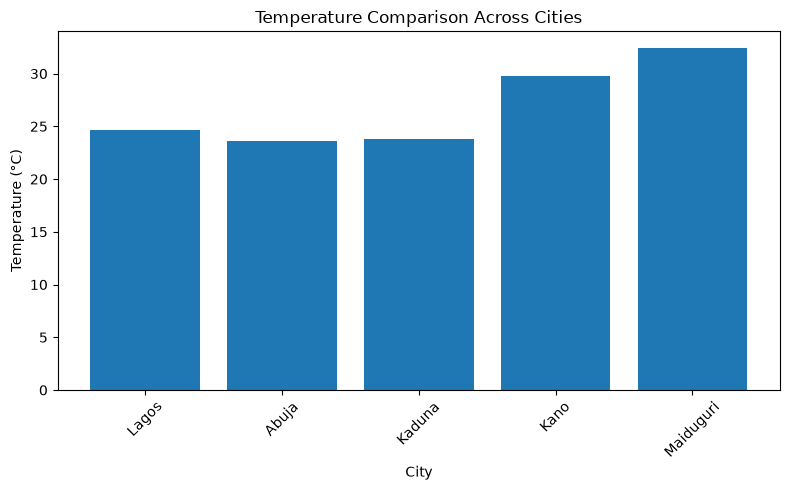

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    weather_df["City"],
    weather_df["Temperature_C"]
)

plt.title("Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

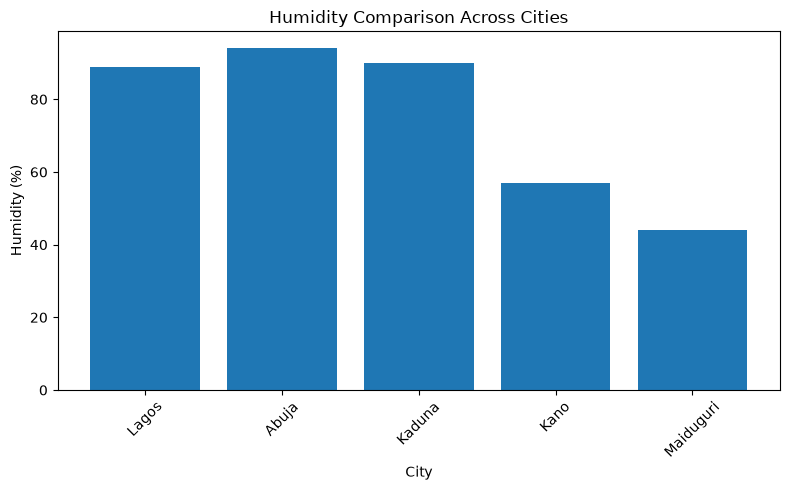

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_df["City"],
    weather_df["Humidity_pct"]
)

plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



## 6. Key Findings

In [27]:
print("Average Temperature:", round(weather_df["Temperature_C"].mean(), 2), "°C")
print("Average Humidity:", round(weather_df["Humidity_pct"].mean(), 2), "%")
print("Average Wind Speed:", round(weather_df["Wind_Speed_mps"].mean(), 2), "m/s")

Average Temperature: 26.85 °C
Average Humidity: 74.8 %
Average Wind Speed: 2.54 m/s


In [28]:
weather_df.describe()

,Temperature_C,Humidity_pct,Wind_Speed_mps,Date_Time
count,5.000000,5.000000,5.000000,5
mean,26.846000,74.800000,2.542000,2026-08-19 18:15:21
min,23.600000,44.000000,1.490000,2026-08-19 18:12:55
25%,23.780000,57.000000,2.110000,2026-08-19 18:14:06
50%,24.690000,89.000000,2.600000,2026-08-19 18:15:07
75%,29.770000,90.000000,3.100000,2026-08-19 18:17:02
max,32.390000,94.000000,3.410000,2026-08-19 18:17:36
std,3.995964,22.731036,0.768355,NaN


In [29]:
weather_df["Weather_Condition"].value_counts()

Weather_Condition
overcast clouds     2
light rain          1
broken clouds       1
scattered clouds    1
Name: count, dtype: int64